# Billionaires Analysis

The goal is to describe the billionaires of the world: who they are, where they live, in which industries they made their fortune and how old they are. The data lists 2,755 billionaires of the Forbes ranking of 2021, with their net worth, country, source of wealth, industry and age (`Billionaire.csv`).

Reference solution: [Billionaires Analysis with Python](https://amanxai.com/2021/06/24/billionaires-analysis-with-python/) (Aman Kharwal). Dataset: [Billionaire.csv](https://raw.githubusercontent.com/amankharwal/Website-data/master/Billionaire.csv).

The reference removes every row with a missing age, draws a chart of the ten richest people and donut charts of the top five countries, sources and industries, and concludes that the United States and China have the most billionaires. This notebook checks what the removal of the missing ages does to the counts, replaces the unreadable chart of the ten richest, and adds the distribution of the wealth and of the age.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Data Visualization/billionaires_analysis')

## Data Loading

In [2]:
data = pd.read_csv("Billionaire.csv")
data["NetWorth"] = data["NetWorth"].str.strip("$ B").astype(float)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2755 entries, 0 to 2754
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      2755 non-null   str    
 1   NetWorth  2755 non-null   float64
 2   Country   2755 non-null   str    
 3   Source    2755 non-null   str    
 4   Rank      2755 non-null   int64  
 5   Age       2676 non-null   float64
 6   Industry  2755 non-null   str    
dtypes: float64(2), int64(1), str(4)
memory usage: 282.5 KB


The net worth is written as text (`$177 B`); the dollar sign and the unit `B` (billions) are removed to get a number. The values are all in billions of dollars.

## Data Cleaning

Only the `Age` column has missing values: 79 of the 2,755 rows (2.9%). The reference removes all these rows from the whole analysis, although the age is only needed for the age charts. The missing ages are not spread evenly: 75% of the billionaires of the United Arab Emirates, 20% of those of Argentina and 15% of those of Germany have no age, so removing the rows changes the count of some countries (see below). The billionaires without an age are also less rich than the others (mean 3.15 billion dollars against 4.75). Three names appear twice in the data, but they are different people (for example two "Robert Miller", one in the United Kingdom and one in Canada, with different net worths), so no row is dropped: the rows are kept and the missing ages are only ignored in the age charts.

In [3]:
print("missing values:", data.isnull().sum()[lambda s: s > 0].to_dict())
missing_age = data[data["Age"].isnull()]
print("net worth of the billionaires without an age: mean", round(missing_age["NetWorth"].mean(), 2), "| median", missing_age["NetWorth"].median(), "| all billionaires: mean", round(data["NetWorth"].mean(), 2), "| median", data["NetWorth"].median())
print("share without an age by country:", data.groupby("Country")["Age"].apply(lambda ages: ages.isnull().mean()).sort_values(ascending=False).head(3).round(2).to_dict())

repeated = data[data["Name"].duplicated(keep=False)][["Name", "NetWorth", "Country", "Rank"]]
repeated.sort_values("Name")

missing values: {'Age': 79}
net worth of the billionaires without an age: mean 3.15 | median 2.2 | all billionaires: mean 4.75 | median 2.3
share without an age by country: {'United Arab Emirates': 0.75, 'Argentina': 0.2, 'Germany': 0.15}


,Name,NetWorth,Country,Rank
693,Li Li,4.2,China,680
1976,Li Li,1.6,China,1931
1331,Robert Miller,2.4,United Kingdom,1299
1625,Robert Miller,2.0,Canada,1580
700,Wang Yanqing & family,4.2,China,680
1919,Wang Yanqing & family,1.7,China,1833


## Reference Reproduction

The chart of the reference for the ten richest people is `sns.histplot(x="Name", hue="NetWorth")`: a histogram of the names, coloured by the net worth, which gives ten bars of the same height and a legend of ten colours. The removal of the missing ages changes the counts of the countries.

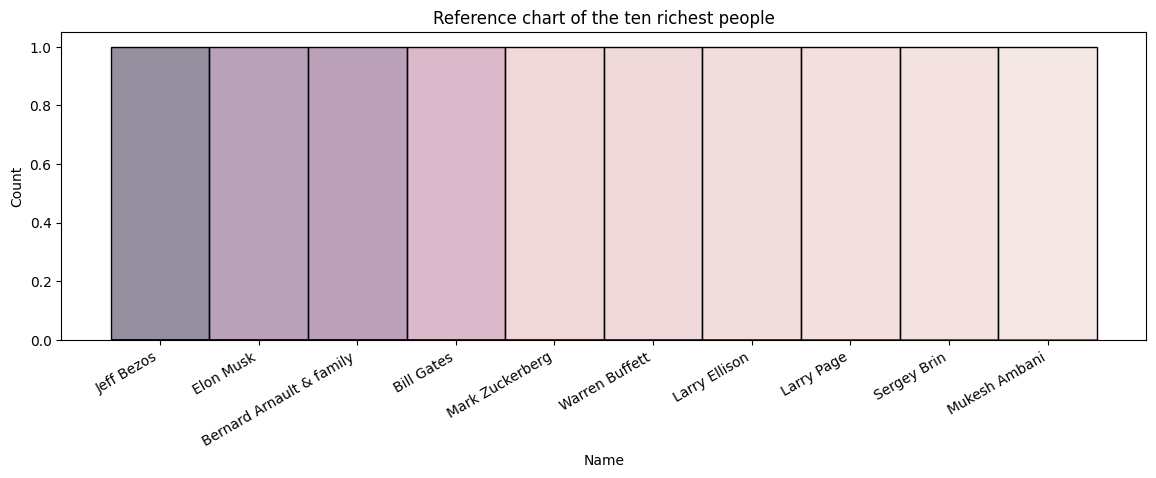

rows removed by the reference: 79 (2.9%)


,all billionaires,reference (missing ages removed),difference
Country,,,
United States,724,720,4
China,626,610,16
India,140,134,6
Germany,136,115,21
Russia,118,118,0
Hong Kong,71,68,3
Brazil,65,61,4
Canada,64,60,4


In [4]:
top10 = data.sort_values("NetWorth", ascending=False).head(10)

plt.figure(figsize=(14, 4))
sns.histplot(x="Name", hue="NetWorth", data=top10, legend=False)
plt.xticks(rotation=30, ha="right"); plt.title("Reference chart of the ten richest people")
plt.show()

counts = pd.DataFrame({"all billionaires": data["Country"].value_counts(), "reference (missing ages removed)": data.dropna()["Country"].value_counts()}).sort_values("all billionaires", ascending=False)
counts["difference"] = counts["all billionaires"] - counts["reference (missing ages removed)"]
print("rows removed by the reference:", len(data) - len(data.dropna()), f"({1 - len(data.dropna()) / len(data):.1%})")
counts.head(8)

The chart of the reference for the ten richest people shows ten bars of the same height, because every name appears once in the data; the net worth is only used for the colour of the bars, so the chart says nothing about who is richest by how much. A horizontal bar chart of the net worth is the right form.

Removing the 79 rows with a missing age also changes the counts of the countries: Germany falls from 136 to 115 billionaires (21 fewer, 15%), China from 626 to 610 and India from 140 to 134. The order of the top five changes as a result: with all billionaires the fourth country is Germany (136) before Russia (118), in the reference table Russia (118) comes before Germany (115). The error is small in total (2.9% of the rows), but it is unnecessary, because the counts do not need the age.

## The Richest People

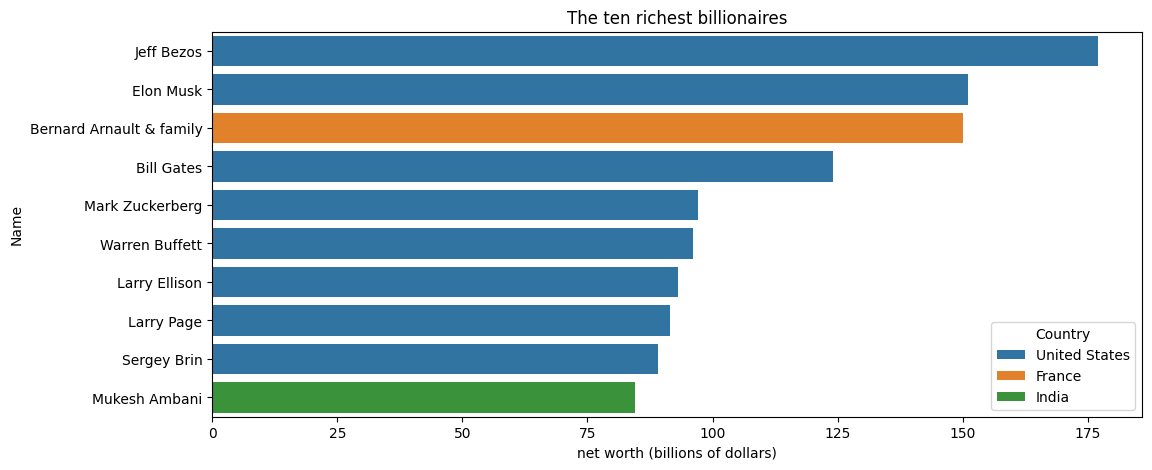

total net worth: 13084 billion dollars | top 10: 8.8% | top 100: 31.8%
mean net worth: 4.7 | median: 2.3


In [5]:
plt.figure(figsize=(12, 5))
sns.barplot(y="Name", x="NetWorth", hue="Country", data=top10, dodge=False)
plt.xlabel("net worth (billions of dollars)"); plt.title("The ten richest billionaires")
plt.show()

total_wealth = data["NetWorth"].sum()
print("total net worth:", round(total_wealth), "billion dollars | top 10:", f"{top10['NetWorth'].sum() / total_wealth:.1%}", "| top 100:", f"{data['NetWorth'].nlargest(100).sum() / total_wealth:.1%}")
print("mean net worth:", round(data["NetWorth"].mean(), 1), "| median:", data["NetWorth"].median())

The ten richest people are Jeff Bezos (177 billion dollars), Elon Musk (151), Bernard Arnault and family (150), Bill Gates (124), Mark Zuckerberg (97), Warren Buffett (96), Larry Ellison (93), Larry Page (91.5), Sergey Brin (89) and Mukesh Ambani (84.5). Eight of them are from the United States, and six made their fortune in technology. Wealth is very concentrated: the top 10 hold 8.8% of the total net worth of 13,084 billion dollars and the top 100 hold 31.8%, while the median billionaire has 2.3 billion dollars, half of the mean (4.7).

## Countries

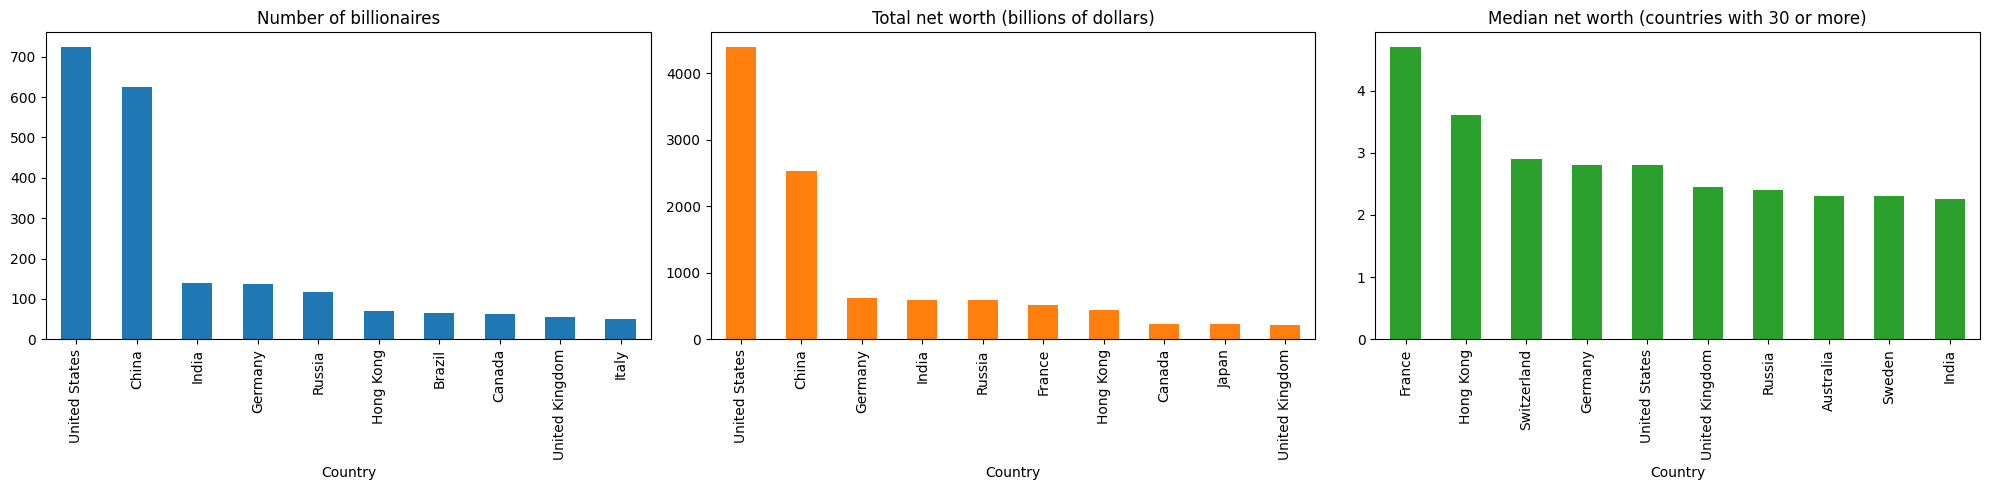

,billionaires,total net worth,median net worth
Country,,,
United States,724,4398.4,2.8
China,626,2531.9,2.0
India,140,596.4,2.2
Germany,136,625.5,2.8
Russia,118,586.0,2.4
Hong Kong,71,448.2,3.6


In [6]:
by_country = data.groupby("Country")["NetWorth"].agg(["count", "sum", "median"]).rename(columns={"count": "billionaires", "sum": "total net worth", "median": "median net worth"})

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
by_country["billionaires"].nlargest(10).plot(kind="bar", ax=axes[0], title="Number of billionaires")
by_country["total net worth"].nlargest(10).plot(kind="bar", ax=axes[1], color="tab:orange", title="Total net worth (billions of dollars)")
by_country[by_country["billionaires"] >= 30]["median net worth"].nlargest(10).plot(kind="bar", ax=axes[2], color="tab:green", title="Median net worth (countries with 30 or more)")
plt.tight_layout(); plt.show()

by_country.sort_values("billionaires", ascending=False).head(6).round(1)

The United States (724 billionaires, 4,398 billion dollars) and China (626 billionaires, 2,532 billion dollars) lead by far: together they have 49% of the billionaires and 53% of the wealth, which confirms the conclusion of the reference. The rankings by number and by wealth are not the same, though: Germany has slightly fewer billionaires than India (136 against 140) but more total wealth (626 against 596 billion dollars), and among the countries with at least 30 billionaires the median fortune is highest in France (4.7 billion dollars), then in Hong Kong (3.6), against 2.8 in the United States and 2.0 in China. The number of billionaires alone says little about a country's business environment, as the reference suggests: the data has no population or economy size to compare with.

## Industries

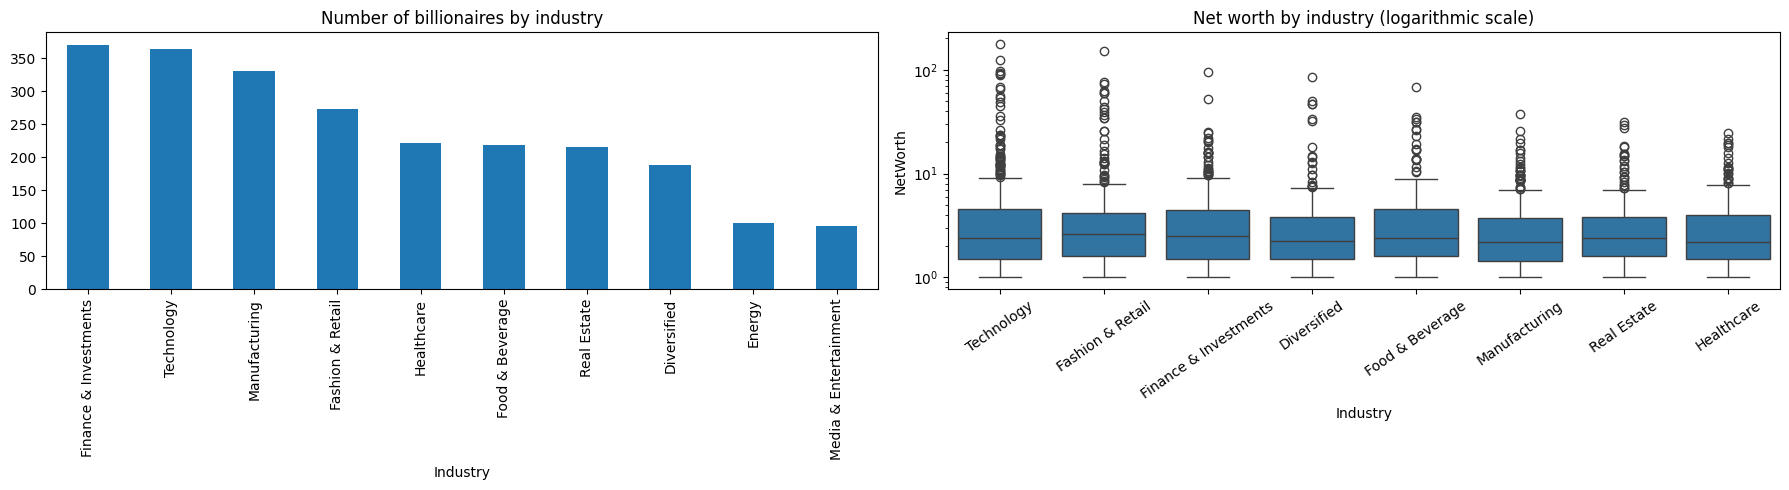

,count,median,max
Industry,,,
Finance & Investments,371,2.5,96.0
Technology,365,2.4,177.0
Manufacturing,331,2.2,37.7
Fashion & Retail,273,2.6,150.0
Healthcare,221,2.2,24.4
Food & Beverage,219,2.4,68.9


In [7]:
main_industries = data["Industry"].value_counts().head(8).index

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
data["Industry"].value_counts().head(10).plot(kind="bar", ax=axes[0], title="Number of billionaires by industry")
sns.boxplot(x="Industry", y="NetWorth", data=data[data["Industry"].isin(main_industries)], ax=axes[1])
axes[1].set_yscale("log"); axes[1].tick_params(axis="x", rotation=35); axes[1].set_title("Net worth by industry (logarithmic scale)")
plt.tight_layout(); plt.show()

data.groupby("Industry")["NetWorth"].agg(["count", "median", "max"]).sort_values("count", ascending=False).head(6).round(1)

Finance and investments (371) and technology (365) are the industries with the most billionaires, followed by manufacturing (331) and fashion and retail (273). The typical fortune is similar in all the industries (a median between 2.2 and 2.6 billion dollars); what differs are the extremes: the largest fortunes are in technology (177 billion) and in fashion and retail (150 billion), each mainly due to one person.

## Age

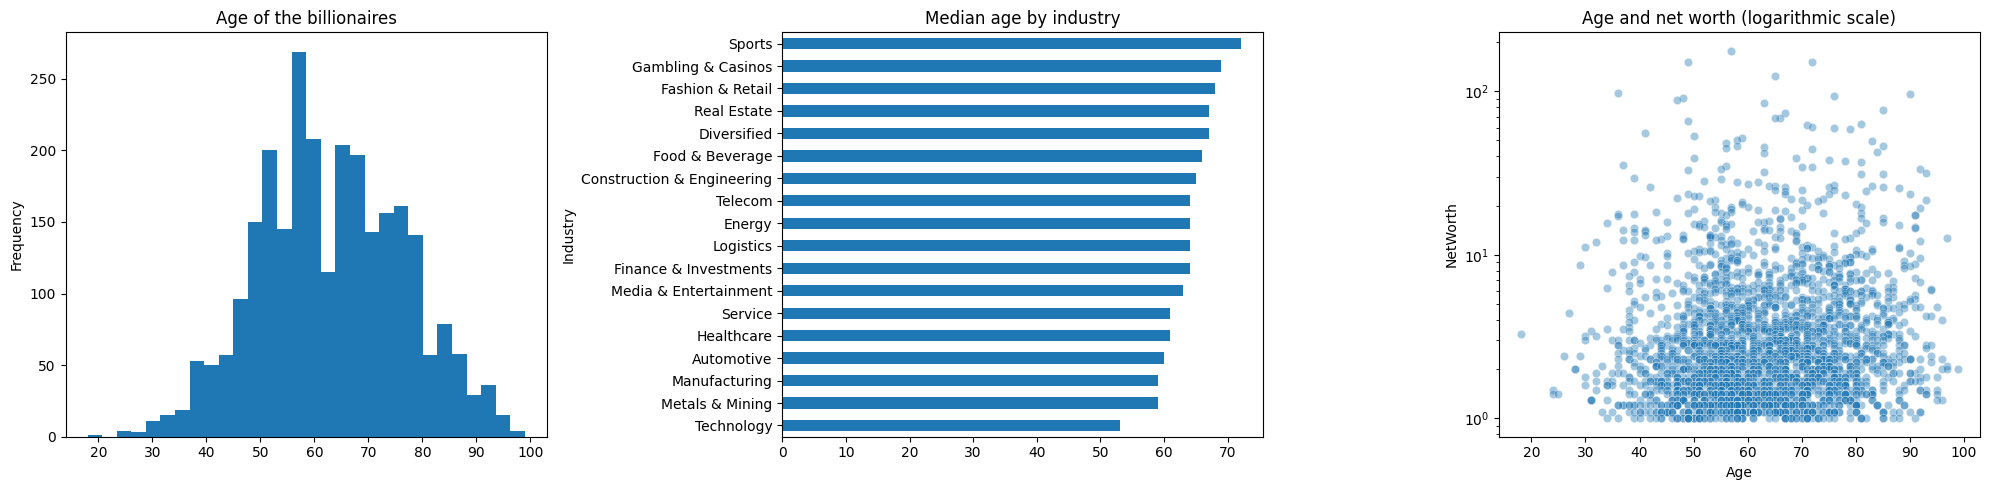

median age: 63.0 | rank correlation between age and net worth: 0.105


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
data["Age"].plot(kind="hist", bins=30, ax=axes[0], title="Age of the billionaires")
data.groupby("Industry")["Age"].median().sort_values().plot(kind="barh", ax=axes[1], title="Median age by industry")
sns.scatterplot(x="Age", y="NetWorth", data=data, alpha=0.4, ax=axes[2]); axes[2].set_yscale("log"); axes[2].set_title("Age and net worth (logarithmic scale)")
plt.tight_layout(); plt.show()

print("median age:", data["Age"].median(), "| rank correlation between age and net worth:", round(data[["Age", "NetWorth"]].corr(method="spearman").iloc[0, 1], 3))

The median billionaire is 63 years old, and ages go from 18 to 99. Technology billionaires are the youngest (a median age of 53), and those of sports (72) and fashion and retail (68) the oldest. Age and net worth are almost unrelated (rank correlation 0.105): the very rich are not older than the others. The age charts leave out the 79 billionaires without age.

## Conclusion

**Reference approach.** The reference removes every billionaire with a missing age, converts the net worth to a number, and draws a chart of the ten richest people and donut charts of the five countries, sources and industries with the most billionaires. It concludes that the United States and China have the most billionaires and reads this as a sign of their business environment.

**Check of the reference.** The chart of the ten richest people (`histplot` of the names coloured by net worth) shows ten bars of the same height and no information. The removal of the 79 rows without an age is not needed for the counts and changes them (Germany 136 to 115, China 626 to 610, India 140 to 134), so the order of the top five countries changes. The conclusion about the United States and China is confirmed by the data.

**Our analysis** (2,755 billionaires, 13,084 billion dollars in total):

| Country | Billionaires | Total net worth (billion dollars) | Median net worth |
|---|---|---|---|
| United States | 724 | 4,398 | 2.8 |
| China | 626 | 2,532 | 2.0 |
| India | 140 | 596 | 2.2 |
| Germany | 136 | 626 | 2.8 |
| Russia | 118 | 586 | 2.4 |
| Hong Kong | 71 | 448 | 3.6 |

The two leading countries hold 49% of the billionaires and 53% of the wealth. The wealth is concentrated (the top 10 hold 8.8% and the top 100 hold 31.8% of the total; median 2.3 against mean 4.7 billion dollars), the typical fortune is the same in every industry (median 2.2 to 2.6 billion) with the extremes in technology and fashion, the median age is 63 (technology billionaires are the youngest, a median of 53) and age has almost no relation to net worth (rank correlation 0.105).

**Limitations.** The data is a single Forbes ranking of 2021 (about a year of the market boom), it only includes people above 1 billion dollars, and net worth is an estimate. The number of billionaires per country cannot be compared without the size of the population or of the economy, which the data does not contain. The age is missing for 79 people, not at random (mostly from the United Arab Emirates). Fortunes of families are counted as one entry ("and family"), which makes counts of people approximate.